In [59]:
import opendatasets as od
import os 
import pandas as pd
import random
import string
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# Download FakeNews text datasets

# Load data

In [2]:
od.download("https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset")

Skipping, found downloaded files in ".\fake-and-real-news-dataset" (use force=True to force download)


In [3]:
target_folder = 'fake-and-real-news-dataset/'
os.listdir(target_folder)

['Fake.csv', 'True.csv']

In [4]:
fake_path = os.path.join(target_folder, 'Fake.csv')
true_path = os.path.join(target_folder, 'True.csv')

In [5]:
fake_data = pd.read_csv(fake_path)
true_data = pd.read_csv(true_path)

# Adding labels to data

In [6]:
true_data['label']=0
true_data.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [7]:
fake_data['label']=1
fake_data.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


# Joining DataFrames

In [8]:
df_fake_news = pd.concat([true_data,fake_data], axis=0)

In [9]:
df_fake_news.head(10)

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0
5,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017",0
6,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017",0
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017",0
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017",0
9,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017",0


In [10]:
# Visualize null values
df_fake_news.isna().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

# Shuffling dataframe samples

In [11]:
df_fake_news = df_fake_news.sample(frac=1., random_state=42)

In [12]:
df_fake_news.head(10)

,title,text,subject,date,label
799,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",1
6500,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",1
3590,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",1
1377,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",0
11059,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",1
5766,"As private lawyer, Trump high court pick was f...",WASHINGTON (Reuters) - As a lawyer in private ...,politicsNews,"February 1, 2017",0
16230,Yemeni Salafist imam killed in Aden: sources,ADEN (Reuters) - A Salafist imam was shot dead...,worldnews,"October 28, 2017",0
20911,FBI says witnesses in U.S. probe into Malaysia...,KUALA LUMPUR (Reuters) - Potential witnesses t...,worldnews,"September 6, 2017",0
14421,An Easy To Read Chart Shows How Bernie Sanders...,The goal of socialism is communism. -Vladimi...,politics,"Feb 24, 2016",1
11738,MMA FIGHTER JAKE SHIELDS Embarrasses Cowards I...,Opposing views and beliefs has much of this co...,politics,"Feb 4, 2017",1


# Drop unecessary columns

In [13]:
df_fake_news.drop(['subject','date','title'], axis=1, inplace=True)

In [14]:
#visualize dataframe columns
df_fake_news.columns

Index(['text', 'label'], dtype='object')

# Data study

##### Visualize random samples

In [15]:
random_idx = random.randint(0, len(df_fake_news)-2)
for row in df_fake_news[random_idx:random_idx+2].itertuples():
    _,text,label=row
    print(f'Text:{text}\nLabel:{label}\n')

Text:After former FBI Director, James Comey was fired from his position as the leader of the FBI by Donald Trump, the thing that is on everyone s mind now is what will Comey do next for work? Will he go back to practicing law?According to this article, Comey testified under oath in front of the Senate Select Committee on Intelligence last Thursday. He accused the President of the United States, who fired him from the FBI, of lying, challenged the president, and even says he has proof of material he supplied that could build a case against the president.However, aside from that, what is next for the former FBI Director? What are his career opportunities? Maybe he will go back to law where he lived comfortably in Connecticut as a lawyer.According to Comey, he stated to the Senate Select Committee on Intelligence when he testified last Thursday that he is currently  between opportunities. Everyone knows James Comey now and what he stands for, whether they are for or against him. Now that 

#### Visualize class balance

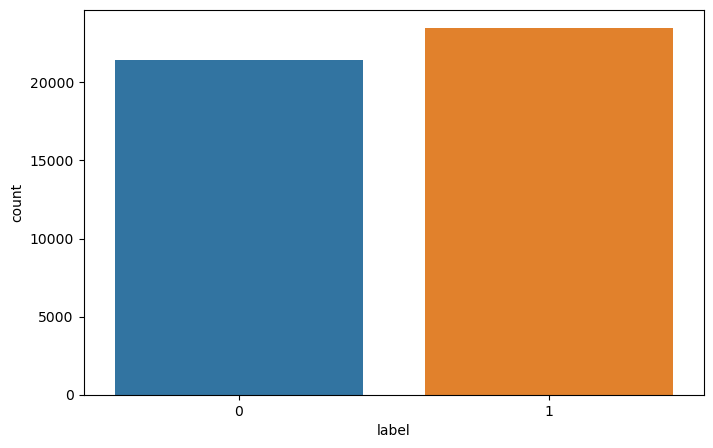

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df_fake_news['label'])
plt.show()

# Data preprocessing

#### Lower text and remove punctuation

In [17]:
def lower_remove_punctuation(text):
    clean_text = ''.join([word for word in text if word not in string.punctuation])
    return clean_text.lower()

In [18]:
#Lower and remove punctuation on text column
df_fake_news['text']=df_fake_news['text'].apply(lambda x: lower_remove_punctuation(x))

In [19]:
# Visualize once again the dataframe
df_fake_news.head(5)

,text,label
799,donald trump s white house is in chaos and the...,1
6500,now that donald trump is the presumptive gop n...,1
3590,mike pence is a huge homophobe he supports exg...,1
1377,san francisco reuters california attorney gen...,0
11059,twisted reasoning is all that comes from pelos...,1


#### Removing possible URLs or HTML tags in text

In [20]:
def remove_urls_html(text):
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    return text

In [21]:
df_fake_news['text']=df_fake_news['text'].apply(lambda x: remove_urls_html(x))

In [22]:
#Visualize once again the dataframe
df_fake_news.head(5)

,text,label
799,donald trump s white house is in chaos and the...,1
6500,now that donald trump is the presumptive gop n...,1
3590,mike pence is a huge homophobe he supports exg...,1
1377,san francisco reuters california attorney gen...,0
11059,twisted reasoning is all that comes from pelos...,1


#### Tokenize text

In [23]:
# Tokenizing text column
df_fake_news['text']=df_fake_news['text'].apply(nltk.word_tokenize)

In [24]:
# Visualize dataframe
df_fake_news.head(5)

,text,label
799,"[donald, trump, s, white, house, is, in, chaos...",1
6500,"[now, that, donald, trump, is, the, presumptiv...",1
3590,"[mike, pence, is, a, huge, homophobe, he, supp...",1
1377,"[san, francisco, reuters, california, attorney...",0
11059,"[twisted, reasoning, is, all, that, comes, fro...",1


#### Stemming text data

In [25]:
stemmer = nltk.PorterStemmer()

In [26]:
df_fake_news['text']=df_fake_news['text'].apply(lambda x: [stemmer.stem(word) for word in x])

In [27]:
#Visualize changes
df_fake_news.head(5)

,text,label
799,"[donald, trump, s, white, hous, is, in, chao, ...",1
6500,"[now, that, donald, trump, is, the, presumpt, ...",1
3590,"[mike, penc, is, a, huge, homophob, he, suppor...",1
1377,"[san, francisco, reuter, california, attorney,...",0
11059,"[twist, reason, is, all, that, come, from, pel...",1


#### Lemmatize text

In [28]:
lemma = nltk.WordNetLemmatizer()

In [29]:
df_fake_news['text']=df_fake_news['text'].apply(lambda x: [lemma.lemmatize(word) for word in x])

In [30]:
df_fake_news

,text,label
799,"[donald, trump, s, white, hous, is, in, chao, ...",1
6500,"[now, that, donald, trump, is, the, presumpt, ...",1
3590,"[mike, penc, is, a, huge, homophob, he, suppor...",1
1377,"[san, francisco, reuter, california, attorney,...",0
11059,"[twist, reason, is, all, that, come, from, pel...",1
...,...,...
11284,"[abuja, reuter, the, unit, state, ha, formal, ...",0
23315,"[tune, in, to, the, altern, current, radio, ne...",1
16741,"[i, m, convinc, the, freedom, from, religion, ...",1
860,"[washington, reuter, the, republican, tax, pla...",0


##### Remove stop words

In [31]:
stop_words = nltk.corpus.stopwords.words('english')
def remove_stop_words(text):
    text = [w for w in text if w not in stop_words]
    return text
df_fake_news['text'] = df_fake_news['text'].apply(lambda x: remove_stop_words(x))

In [32]:
df_fake_news['text'] = df_fake_news['text'].apply(lambda x: str.join(', ', x))

In [33]:
df_fake_news

,text,label
799,"donald, trump, white, hous, chao, tri, cover, ...",1
6500,"donald, trump, presumpt, gop, nomine, time, re...",1
3590,"mike, penc, huge, homophob, support, exgay, co...",1
1377,"san, francisco, reuter, california, attorney, ...",0
11059,"twist, reason, come, pelosi, day, especi, 2006...",1
...,...,...
11284,"abuja, reuter, unit, state, ha, formal, agre, ...",0
23315,"tune, altern, current, radio, network, acr, an...",1
16741,"convinc, freedom, religion, group, atheist, ge...",1
860,"washington, reuter, republican, tax, plan, unv...",0


#### Splitting dataframe into training and test sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(df_fake_news['text'].to_numpy(),
                                                    df_fake_news['label'].to_numpy(),
                                                    test_size=0.3,
                                                    shuffle=True,stratify=df_fake_news['label'],
                                                    random_state=42)

In [38]:
X_train.shape,y_train.shape, X_test.shape,y_test.shape

((31428,), (31428,), (13470,), (13470,))

## Model_0 : Naive Bayes classifier

In [43]:
model_0 = Pipeline([('tfidf', CountVectorizer()),('clf',MultinomialNB())])

In [44]:
model_0.fit(X_train, y_train)

Pipeline(steps=[('tfidf', CountVectorizer()), ('clf', MultinomialNB())])

#### Evaluate the model on test data

Naive Bayes model achieved an accuracy of:95.25%


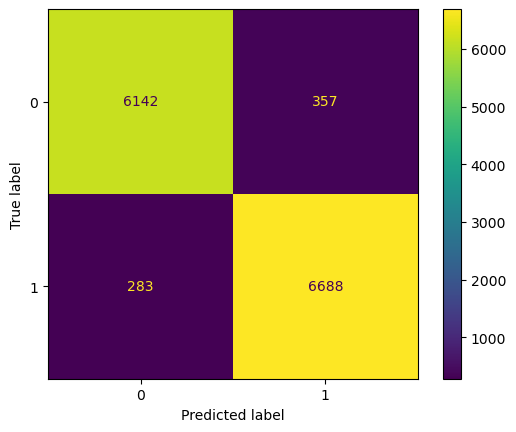

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      6499
           1       0.95      0.96      0.95      6971

    accuracy                           0.95     13470
   macro avg       0.95      0.95      0.95     13470
weighted avg       0.95      0.95      0.95     13470



In [58]:
# make some predictions 
model_0_preds = model_0.predict(X_test)

# evaluate model
print(f'Naive Bayes model achieved an accuracy of:{accuracy_score(model_0_preds, y_test)*100:.2f}%')
ConfusionMatrixDisplay.from_predictions(model_0_preds, y_test)
plt.show()
print(classification_report(model_0_preds, y_test))

# Model_1 : RandomForestClassifier

In [61]:
model_1.fit(X_train, y_train)

Pipeline(steps=[('tfidf', CountVectorizer()),
                ('clf', RandomForestClassifier())])

In [60]:
model_1 = Pipeline([('tfidf', CountVectorizer()),
                    ('clf',RandomForestClassifier())])

RandomForest model achieved an accuracy of:98.60%


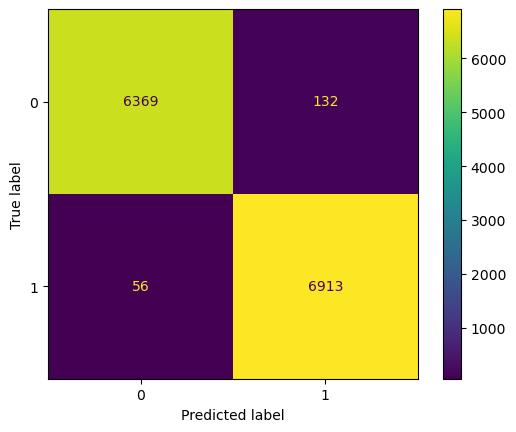

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      6501
           1       0.98      0.99      0.99      6969

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



In [62]:
# make some predictions 
model_1_preds = model_1.predict(X_test)

# evaluate model
print(f'RandomForest model achieved an accuracy of:{accuracy_score(model_1_preds, y_test)*100:.2f}%')
ConfusionMatrixDisplay.from_predictions(model_1_preds, y_test)
plt.show()
print(classification_report(model_1_preds, y_test))